In [28]:
import sys, os

import torch
import torch.nn.functional as F
import pandas as pd

CKPT_PATH = "fox.ckpt"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

from training.model import Fox

ckpt = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
hp   = ckpt["hparams"]

# Infer num_cross_layers from state dict (not stored in hparams)
num_cross_layers = max(
    int(k.split(".")[1]) for k in ckpt["model"] if k.startswith("cross_attn_h2p.")
) + 1

model = Fox(
    hidden_dim            = 256,
    pair_dim              = hp.get("pair_dim", 64),
    num_heads             = 8,
    axial_layers          = hp.get("axial_layers", 2),
    use_opm               = hp.get("use_opm", False),
    use_dist_matrix       = True,
    gradient_checkpointing= False,
    num_cross_layers      = num_cross_layers,
    cls_dim               = hp.get("cls_dim", 512),
    use_flexattention     = False,   # FlexAttention needs CUDA; disabled for local inference
    dropout               = 0.0,
)
model.load_state_dict(ckpt["model"])
model.to(device).eval()
print(f"Model loaded ({num_cross_layers} cross layers, {sum(p.numel() for p in model.parameters()):,} params)")

Model loaded (2 cross layers, 47,978,630 params)


In [29]:
# ── Encoding utilities (mirrors pre_encoder.py) ─────────────────────
import re

AMINO_ACIDS = "ACDEFGHIKLMNPQRSTVWY-"
AA_TO_INDEX = {aa: i for i, aa in enumerate(AMINO_ACIDS)}
UNK_ID, PAD_ID = 21, 22
MAX_SEQ_LEN = 250

def encode_sequence(seq, max_len=MAX_SEQ_LEN):
    enc = [AA_TO_INDEX.get(aa, UNK_ID) for aa in seq[:max_len]]
    enc += [PAD_ID] * (max_len - len(enc))
    return torch.tensor(enc, dtype=torch.long)

def jukes_cantor_dist(msa: torch.Tensor) -> torch.Tensor:
    valid = (msa != PAD_ID)
    valid_pair = valid.unsqueeze(1) & valid.unsqueeze(0)
    n_v = valid_pair.sum(dim=2).clamp(min=1).float()
    mismatch = (msa.unsqueeze(1) != msa.unsqueeze(0)) & valid_pair
    p = mismatch.float().sum(dim=2) / n_v
    p = p.clamp(0.0, 0.74)
    dist = -0.75 * torch.log(1.0 - (4.0 / 3.0) * p)
    dist.fill_diagonal_(0.0)
    return dist

def load_pt(path):
    s = torch.load(path, map_location="cpu", weights_only=False)
    if "host_msa" in s:
        return s["host_msa"], s["para_msa"], s["host_dist"], s["para_dist"], s["mappings"], s.get("labels")
    host_msas = s["host_msas"]
    para_msas = s["parasite_msas"]
    h_idx = {n: i for i, n in enumerate(host_msas)}
    p_idx = {n: i for i, n in enumerate(para_msas)}
    host_tok = torch.stack([encode_sequence(seq) for seq in host_msas.values()])
    para_tok = torch.stack([encode_sequence(seq) for seq in para_msas.values()])
    raw_mappings = s["mappings"]
    if raw_mappings and isinstance(raw_mappings[0], (tuple, list)) and isinstance(raw_mappings[0][0], str):
        mappings = [(h_idx[h], p_idx[p]) for p, h in raw_mappings if p in p_idx and h in h_idx]
    else:
        mappings = raw_mappings
    _hd = s.get("host_dist")
    _pd = s.get("para_dist")
    host_dist = _hd if _hd is not None else jukes_cantor_dist(host_tok)
    para_dist = _pd if _pd is not None else jukes_cantor_dist(para_tok)
    labels = s.get("event_frequencies") if s.get("event_frequencies") is not None else s.get("labels")
    return host_tok, para_tok, host_dist, para_dist, mappings, labels

_FREQ_KEYS = {"Speciation_freq": "Speciation", "HGT_freq": "HGT",
              "Loss_freq": "Loss", "Duplication_freq": "Duplication", "Sim_time": "Sim_time"}

def parse_tgl(path):
    result = dict(host_tree=None, para_tree=None,
                  host_msa={}, para_msa={},
                  distribution=[], event_freqs={})
    section, in_aln = None, False
    with open(path) as f:
        for line in f:
            s = line.strip()
            if s.startswith("BEGIN HOST;"):
                section, in_aln = "HOST", False; continue
            elif s.startswith("BEGIN PARASITE;"):
                section, in_aln = "PARA", False; continue
            elif s.startswith("BEGIN DISTRIBUTION;"):
                section = "DIST"; continue
            elif s in ("ENDBLOCK;", "END;"):
                section, in_aln = None, False; continue
            if section in ("HOST", "PARA"):
                import re as _re
                m = _re.match(r"TREE \* \S+ = (.+)", s)
                if m:
                    key = "host_tree" if section == "HOST" else "para_tree"
                    result[key] = m.group(1).rstrip(";"); continue
                if s.startswith("ALIGNMENT"):
                    in_aln = True; continue
                if in_aln and s == "'":
                    in_aln = False; continue
                if in_aln:
                    parts = s.split()
                    if len(parts) == 2:
                        d = result["host_msa"] if section == "HOST" else result["para_msa"]
                        d[parts[0]] = parts[1]
            elif section == "DIST":
                if ":" in s:
                    p, h = [x.strip() for x in s.split(":", 1)]
                    result["distribution"].append((p, h))
            else:
                for raw_key, std_key in _FREQ_KEYS.items():
                    if s.startswith(raw_key + ":"):
                        try:
                            result["event_freqs"][std_key] = float(s.split(":", 1)[1].strip())
                        except ValueError:
                            pass
    return result

def load_tgl(path):
    d = parse_tgl(path)
    host_msas, para_msas = d["host_msa"], d["para_msa"]
    h_idx = {n: i for i, n in enumerate(host_msas)}
    p_idx = {n: i for i, n in enumerate(para_msas)}
    host_tok = torch.stack([encode_sequence(seq) for seq in host_msas.values()])
    para_tok = torch.stack([encode_sequence(seq) for seq in para_msas.values()])
    mappings = [(h_idx[h], p_idx[p])
                for p, h in d["distribution"] if p in p_idx and h in h_idx]
    labels = d["event_freqs"] or None
    return host_tok, para_tok, jukes_cantor_dist(host_tok), jukes_cantor_dist(para_tok), mappings, labels

print("Encoding utilities ready.")

Encoding utilities ready.


In [30]:
# ── Inference on a list of files ─────────────────────────────────────────────
EVENT_NAMES = ["Speciation", "HGT", "Loss", "Duplication"]

def predict(paths, sim_time=None):
    """
    paths    : list of .pt or .tgl file paths
    sim_time : float or None (defaults to 1.0 if unknown)
    Returns  : pd.DataFrame with columns file, pred_*, [true_* if labels present]
    """
    rows = []
    with torch.no_grad():
        for path in paths:
            ext = os.path.splitext(path)[1].lower()
            if ext == ".pt":
                host_msa, para_msa, host_dist, para_dist, mappings, labels = load_pt(path)
            elif ext == ".tgl":
                host_msa, para_msa, host_dist, para_dist, mappings, labels = load_tgl(path)
            else:
                raise ValueError(f"Unknown extension {ext!r} — expected .pt or .tgl")

            t = torch.tensor([[sim_time if sim_time is not None else
                                (labels.get("Sim_time", 1.0) if isinstance(labels, dict) else 1.0)]],
                             dtype=torch.float32, device=device)

            out = model(
                host_msa.unsqueeze(0).to(device),
                para_msa.unsqueeze(0).to(device),
                [mappings],
                t,
                host_dist=host_dist.unsqueeze(0).to(device),
                para_dist=para_dist.unsqueeze(0).to(device),
            )  # [1, 4]

            pred = out.squeeze(0).cpu().tolist()
            row  = {"file": os.path.basename(path)}
            row.update({f"pred_{n}": v for n, v in zip(EVENT_NAMES, pred)})

            if isinstance(labels, dict):
                row.update({f"true_{n}": labels.get(n, float("nan")) for n in EVENT_NAMES})

            rows.append(row)

    return pd.DataFrame(rows)

print("predict() ready.")

predict() ready.


In [31]:
DATA_DIR = "/Users/gabriele/Fox/test_data/fox_data"   

import glob
files = sorted(glob.glob(os.path.join(DATA_DIR, "*.pt")))

print(f"Found {len(files)} files")
df = predict(files)
df['speciation_diff'] = df['pred_Speciation'] -  df['true_Speciation']
df['HGT_diff'] = df['pred_HGT'] - df['true_HGT']
df['Loss_diff'] = df['pred_Loss'] - df['true_Loss']
df['Duplication_diff'] = df['pred_Duplication'] - df['true_Duplication']
print(df)

Found 100 files


KeyboardInterrupt: 

In [5]:
from scipy import stats
from sklearn.metrics import r2_score
import numpy as np

rows_metrics = []
for event in EVENT_NAMES:
    true = df[f"true_{event}"].values
    pred = df[f"pred_{event}"].values
    diff = pred - true
    mae  = np.abs(diff).mean()
    rmse = np.sqrt((diff**2).mean())
    r2   = r2_score(true, pred)
    bias = diff.mean()
    rows_metrics.append({
        "Event": event,
        "MAE": mae,
        'MRE': mae / np.mean(true) if np.mean(true) > 0 else 1e-6,
        "RMSE": rmse,
        "R²": r2,
        "Bias": bias,
    })

metrics_df = pd.DataFrame(rows_metrics).set_index("Event")
print(metrics_df.round(4))


                MAE     MRE    RMSE      R²    Bias
Event                                              
Speciation   0.0237  0.0408  0.0302  0.9082  0.0079
HGT          0.0249  0.2084  0.0321  0.5950 -0.0109
Loss         0.0162  0.1295  0.0217  0.8344 -0.0001
Duplication  0.0208  0.1206  0.0267  0.6413  0.0030


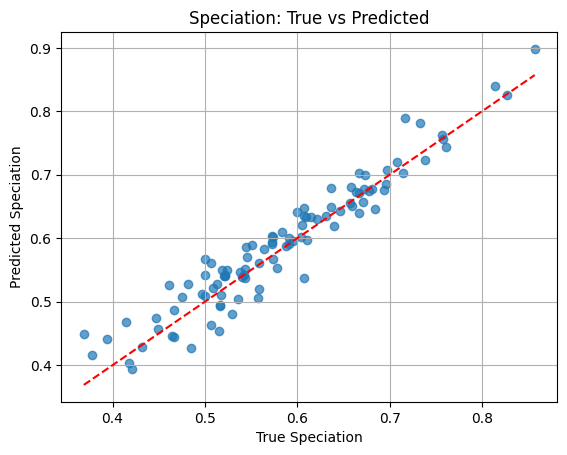

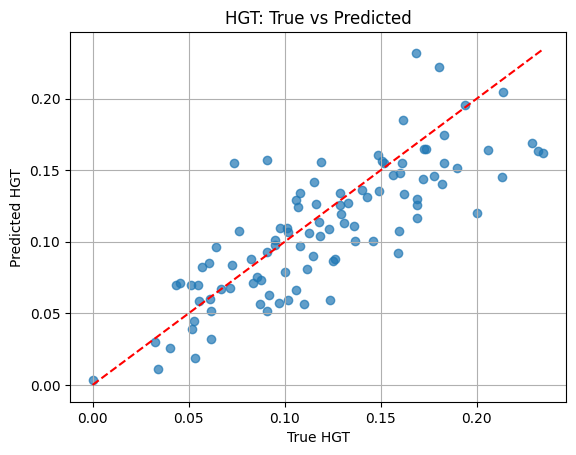

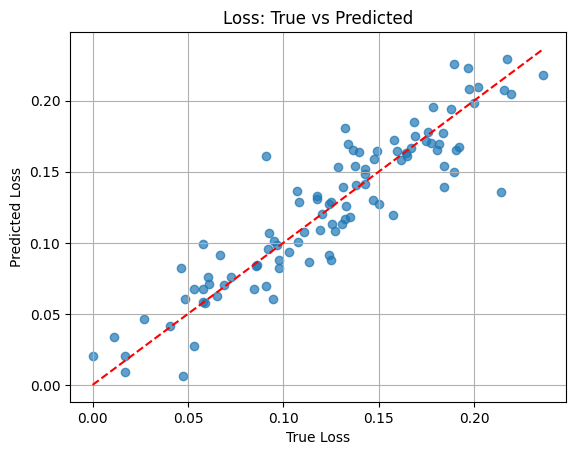

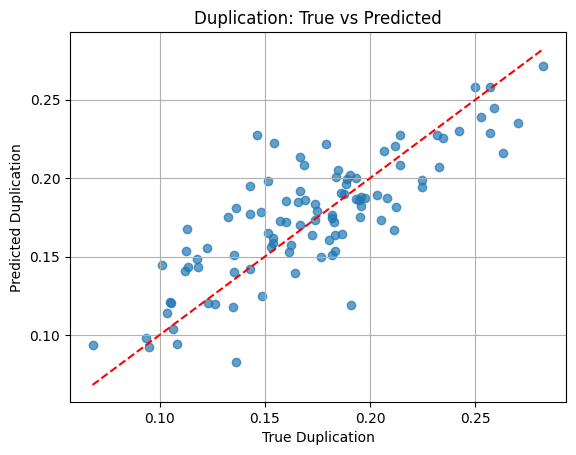

In [ ]:
# plot true vs predicted
import matplotlib.pyplot as plt
for event in EVENT_NAMES:   
    plt.figure()
    plt.scatter(df[f"true_{event}"], df[f"pred_{event}"], alpha=0.7)
    plt.plot([df[f"true_{event}"].min(), df[f"true_{event}"].max()],
             [df[f"true_{event}"].min(), df[f"true_{event}"].max()], 'r--')
    plt.xlabel(f"True {event}")
    plt.ylabel(f"Predicted {event}")
    plt.title(f"{event}: True vs Predicted")
    plt.grid()
    plt.tight_layout()
    plt.show()

## AmoCoala comparison on simulated test data



In [7]:
import os, subprocess, glob
import re
import numpy as np
import pandas as pd
from tqdm import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed
import time, threading

TGL_DIR    = "/Users/gabriele/Fox/test_data/Datasets"
SIM_AC_DIR = "/Users/gabriele/Fox/test_data/amocoala_data"
os.makedirs(SIM_AC_DIR, exist_ok=True)

AMOCOALA_JAR = "/Users/gabriele/AmoCoala-main/AmoCoala.jar"
TEST_N_SIM   = None  # set to int to limit, e.g. 10

_STRIP_BL  = re.compile(r":[0-9eE+\-.]*[0-9]")
_STRIP_INT = re.compile(r"\)[A-Za-z0-9_]+")

def _parse_newick_subtrees(nwk):
    nwk = _STRIP_BL.sub("", nwk.strip().rstrip(";"))
    subtree_leaves = {}
    def parse(s, pos):
        if s[pos] == "(":
            pos += 1
            all_leaves = []
            while pos < len(s) and s[pos] != ")":
                child_leaves, pos, _ = parse(s, pos)
                all_leaves.extend(child_leaves)
                if pos < len(s) and s[pos] == ",":
                    pos += 1
            pos += 1
            name_start = pos
            while pos < len(s) and s[pos] not in ",)(":
                pos += 1
            node_name = s[name_start:pos].strip()
            if node_name:
                subtree_leaves[node_name] = set(all_leaves)
            return all_leaves, pos, node_name
        else:
            name_start = pos
            while pos < len(s) and s[pos] not in ",)":
                pos += 1
            leaf_name = s[name_start:pos].strip()
            if leaf_name:
                subtree_leaves[leaf_name] = {leaf_name}
            return [leaf_name], pos, leaf_name
    parse(nwk, 0)
    return subtree_leaves

def _collapse_unary(nwk):
    # AmoCoala's addVerticalSpread only handles binary internal nodes (Tree.java:1018).
    # Unary internals -> entries missing from mapVerticalSpreadAssociations -> NPE at line 1125.
    nwk = nwk.strip().rstrip(";")
    pos = [0]
    def parse():
        if pos[0] < len(nwk) and nwk[pos[0]] == "(":
            pos[0] += 1
            ch = [parse()]
            while pos[0] < len(nwk) and nwk[pos[0]] == ",":
                pos[0] += 1; ch.append(parse())
            pos[0] += 1  # )
            ns = pos[0]
            while pos[0] < len(nwk) and nwk[pos[0]] not in ",()":
                pos[0] += 1
            return (nwk[ns:pos[0]], ch)
        ns = pos[0]
        while pos[0] < len(nwk) and nwk[pos[0]] not in ",()":
            pos[0] += 1
        return (nwk[ns:pos[0]], None)
    def simplify(node):
        label, ch = node
        if ch is None: return node
        new_ch = [simplify(c) for c in ch]
        if len(new_ch) == 1: return new_ch[0]
        return (label, new_ch)
    def ser(node):
        label, ch = node
        if ch is None: return label
        return "(" + ",".join(ser(c) for c in ch) + ")" + label
    return ser(simplify(parse()))

def _expand_dist(distribution, host_nwk):
    st = _parse_newick_subtrees(host_nwk)
    all_leaves = {n for n, v in st.items() if v == {n}}
    expanded, seen = [], set()
    for p, h in distribution:
        targets = [h] if h in all_leaves else sorted(st.get(h, []))
        for t in targets:
            if (p, t) not in seen:
                expanded.append((p, t))
                seen.add((p, t))
    return expanded

def run_amocoala_on_tgl(tgl_path, out_dir):
    os.makedirs(out_dir, exist_ok=True)
    stem       = os.path.splitext(os.path.basename(tgl_path))[0]
    nex_path   = os.path.join(out_dir, f"{stem}.nex")
    result_csv = f"{nex_path}.accep.round_1.csv"
    if os.path.exists(result_csv):
        return result_csv, None
    d = parse_tgl(tgl_path)
    if d["host_tree"] is None or d["para_tree"] is None:
        return None, "Could not parse trees"
    expanded_dist = _expand_dist(d["distribution"], d["host_tree"])
    host_nwk = _collapse_unary(_STRIP_INT.sub(")", _STRIP_BL.sub("", d["host_tree"])))
    para_nwk = _collapse_unary(_STRIP_INT.sub(")", _STRIP_BL.sub("", d["para_tree"])))
    host_leaves = {n for n, v in _parse_newick_subtrees(host_nwk).items() if v == {n}}
    para_leaves = {n for n, v in _parse_newick_subtrees(para_nwk).items() if v == {n}}
    expanded_dist = [(p, h) for p, h in expanded_dist if p in para_leaves and h in host_leaves]
    if len(expanded_dist) < 3:
        return None, f"Too few valid leaf mappings: {len(expanded_dist)}"
    map_strs = [f"{p} : {h}" for p, h in expanded_dist]
    nexus = (
        "#NEXUS\n"
        f"BEGIN HOST;\n\tTREE HOST = {host_nwk};\nENDBLOCK;\n"
        f"BEGIN PARASITE;\n\tTREE PARASITE = {para_nwk};\nENDBLOCK;\n"
        "BEGIN DISTRIBUTION;\n\tRANGE\n\t\t"
        + ", ".join(map_strs)
        + ";\nENDBLOCK;\n"
    )
    with open(nex_path, "w") as f:
        f.write(nexus)
    r = subprocess.run(
        f"java -jar {AMOCOALA_JAR} -input {nex_path} -N 1000 -M 100 -R 1 -t 0.1",
        shell=True, capture_output=True, text=True, timeout=6000)
    if os.path.exists(result_csv):
        return result_csv, None
    return None, (r.stderr or r.stdout)[:300]


all_tgls = sorted(glob.glob(os.path.join(TGL_DIR, "*.tgl")))
if TEST_N_SIM and TEST_N_SIM < len(all_tgls):
    idx = [round(i * (len(all_tgls) - 1) / (TEST_N_SIM - 1)) for i in range(TEST_N_SIM)]
    run_tgls = [all_tgls[i] for i in idx]
else:
    run_tgls = all_tgls

print(f"Running AmoCoala on {len(run_tgls)} datasets (true trees, no IQ-TREE):")

def _run_one(args):
    tgl_path, out_dir = args
    t0 = time.time()
    print(f"[{time.strftime('%H:%M:%S')}] START {os.path.basename(tgl_path)}", flush=True)
    csv, err = run_amocoala_on_tgl(tgl_path, out_dir)
    elapsed = time.time() - t0
    status = 'OK' if csv else 'FAIL'
    print(f"[{time.strftime('%H:%M:%S')}] {status} {os.path.basename(tgl_path)} ({elapsed:.0f}s)", flush=True)
    return tgl_path, csv, err

jobs = [(p, os.path.join(SIM_AC_DIR, os.path.splitext(os.path.basename(p))[0])) for p in run_tgls]
failed_sim = []
with ThreadPoolExecutor(max_workers=min(len(run_tgls), os.cpu_count())) as ex:
    futures = {ex.submit(_run_one, j): j for j in jobs}
    for fut in tqdm(as_completed(futures), total=len(jobs)):
        tgl_path, csv, err = fut.result()
        if csv is None:
            failed_sim.append((os.path.basename(tgl_path), err))

n_done = len(run_tgls) - len(failed_sim)
print(f"\nDone: {n_done} / {len(run_tgls)}")
if failed_sim:
    print("Failed:", failed_sim)

Running AmoCoala on 40 datasets (true trees, no IQ-TREE):
[14:13:16] START Dataset11.tgl
[14:13:16] START Dataset12.tgl
[14:13:16] START Dataset16.tgl
[14:13:16] START Dataset17.tgl
[14:13:16] START Dataset18.tgl
[14:13:16] OK Dataset11.tgl (0s)
[14:13:16] START Dataset26.tgl
[14:13:16] OK Dataset12.tgl (0s)
[14:13:16] OK Dataset16.tgl (0s)
[14:13:16] START Dataset27.tgl
[14:13:16] START Dataset28.tgl[14:13:16] START Dataset30.tgl
[14:13:16] START Dataset31.tgl
[14:13:16] START Dataset32.tgl

[14:13:16] OK Dataset17.tgl (0s)
[14:13:16] START Dataset33.tgl
[14:13:16] OK Dataset18.tgl (0s)
[14:13:16] START Dataset35.tgl
[14:13:16] OK Dataset26.tgl (0s)
[14:13:16] START Dataset36.tgl
[14:13:16] START Dataset37.tgl
[14:13:16] OK Dataset30.tgl (0s)
[14:13:16] OK Dataset27.tgl (0s)
[14:13:16] OK Dataset28.tgl (0s)
[14:13:16] START Dataset38.tgl
[14:13:16] OK Dataset32.tgl (0s)
[14:13:16] START Dataset39.tgl
[14:13:16] START Dataset40.tgl
[14:13:16] START Dataset46.tgl[14:13:16] OK Dataset35.

  0%|          | 0/40 [00:00<?, ?it/s]

[14:13:16] OK Dataset84.tgl (0s)[14:13:16] OK Dataset94.tgl (0s)
[14:13:16] OK Dataset87.tgl (0s)

[14:13:16] OK Dataset99.tgl (0s)
[14:13:16] OK Dataset89.tgl (0s)
[14:13:16] OK Dataset98.tgl (0s)
[14:13:16] OK Dataset96.tgl (0s)
[14:13:16] OK Dataset97.tgl (0s)


100%|██████████| 40/40 [00:00<00:00, 43565.87it/s]


Done: 40 / 40


8 hours and 40 minutes -> 41 datasets done by amocoala -> It stopped since it was taking too much time to do some datasets 

In [8]:
# Reuse predictions from df (cell In[4]) — already ran model on all .pt in DATA_DIR.
# Map each .tgl -> matching .pt by event_frequencies tuple, then filter df.
PT_DIR = DATA_DIR  # same folder used by In[4]

_FREQ_FIELDS = ["Speciation", "HGT", "Loss", "Duplication", "Sim_time"]
def _label_key(freqs):
    return tuple(round(float(freqs.get(k, 0.0)), 5) for k in _FREQ_FIELDS)

pt_index = {}
for p in sorted(glob.glob(os.path.join(PT_DIR, "*.pt"))):
    s = torch.load(p, map_location="cpu", weights_only=False)
    freqs = s.get("event_frequencies") or s.get("labels")
    if isinstance(freqs, dict):
        pt_index[_label_key(freqs)] = os.path.basename(p)

run_tgls = all_tgls
pt_to_tgl_name, missing = {}, []
for tgl in run_tgls:
    freqs = parse_tgl(tgl)["event_freqs"]
    pt_name = pt_index.get(_label_key(freqs))
    if pt_name is None:
        missing.append(os.path.basename(tgl))
    else:
        pt_to_tgl_name[pt_name] = os.path.basename(tgl)
if missing:
    print(f"WARNING: no .pt match for {len(missing)} tgls: {missing[:5]}...")

df_tgl_pred = df[df["file"].isin(pt_to_tgl_name)].copy()
df_tgl_pred["file"] = df_tgl_pred["file"].map(pt_to_tgl_name)
print("reused", len(df_tgl_pred), "predictions from df (no re-inference)")

reused 40 predictions from df (no re-inference)


In [9]:
# ── Parse AmoCoala results + 3-way comparison ─────────────────────
import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import r2_score

SIM_AC_DIR = "/Users/gabriele/Fox/test_data/amocoala_data"
def _parse_ac_csv(csv_path):
    rows = []
    with open(csv_path) as f:
        for line in f:
            vals = [float(x) for x in line.strip().split("\t") if x.strip()]
            if len(vals) >= 4:
                rows.append(vals)
    if not rows:
        return None
    arr = np.array(rows)
    cospec, dup, hsw, loss = arr[:,0].mean(), arr[:,1].mean(), arr[:,2].mean(), arr[:,3].mean()
    total = cospec + dup + hsw + loss or 1.0
    return {"Speciation": cospec/total, "Duplication": dup/total,
            "HGT": hsw/total, "Loss": loss/total}

ac_rows = []
for tgl_path in run_tgls:
    stem = os.path.splitext(os.path.basename(tgl_path))[0]
    csv  = os.path.join(SIM_AC_DIR, stem, f"{stem}.nex.accep.round_1.csv")
    if not os.path.exists(csv):
        continue
    freqs = _parse_ac_csv(csv)
    if freqs is None:
        continue
    true = parse_tgl(tgl_path)["event_freqs"]
    row  = {"file": f"{stem}.tgl"}
    row.update({f"ac_{e}":   freqs.get(e, float("nan")) for e in EVENT_NAMES})
    row.update({f"true_{e}": true.get(e,  float("nan")) for e in EVENT_NAMES})
    ac_rows.append(row)

df_sac  = pd.DataFrame(ac_rows)
df_cmp3 = df_sac.merge(
    df_tgl_pred[["file"] + [f"pred_{e}" for e in EVENT_NAMES]],
    on="file", how="inner")
print(f"Matched: {len(df_cmp3)} samples")
print(df_cmp3[["file"]
              + [f"true_{e}" for e in EVENT_NAMES]
              + [f"ac_{e}"   for e in EVENT_NAMES]
              + [f"pred_{e}" for e in EVENT_NAMES]].to_string(index=False))

rows_ac, rows_mdl = [], []
for event in EVENT_NAMES:
    t = df_cmp3[f"true_{event}"].values
    a = df_cmp3[f"ac_{event}"].values
    p = df_cmp3[f"pred_{event}"].values
    rows_ac.append({"Event": event,
        "MAE":  np.abs(a-t).mean(), 'MRE': np.abs(a-t).mean() / np.mean(t) if np.mean(t) > 0 else 1e-6,
        'RMSE': np.sqrt(((a-t)**2).mean()),
        "R2":   r2_score(t, a),     "Pearson r": stats.pearsonr(t, a)[0]})
    rows_mdl.append({"Event": event,
        "MAE":  np.abs(p-t).mean(), 'MRE': np.abs(p-t).mean() / np.mean(t) if np.mean(t) > 0 else 1e-6,
        'RMSE': np.sqrt(((p-t)**2).mean()),
        "R2":   r2_score(t, p),     "Pearson r": stats.pearsonr(t, p)[0]})

df_mtr_ac  = pd.DataFrame(rows_ac).set_index("Event")
df_mtr_mdl = pd.DataFrame(rows_mdl).set_index("Event")
print("\n=== AmoCoala vs truth ===")
print(df_mtr_ac.round(4))
print("\n=== Model vs truth (same subset) ===")
print(df_mtr_mdl.round(4))

Matched: 40 samples
         file  true_Speciation  true_HGT  true_Loss  true_Duplication  ac_Speciation   ac_HGT  ac_Loss  ac_Duplication  pred_Speciation  pred_HGT  pred_Loss  pred_Duplication
Dataset11.tgl           0.8276    0.0517     0.0172            0.1034       0.484580 0.186775 0.232599        0.096047         0.826081  0.039045   0.020559          0.114315
Dataset12.tgl           0.6667    0.1014     0.0580            0.1739       0.522067 0.180962 0.215325        0.081646         0.639342  0.109361   0.067539          0.183759
Dataset16.tgl           0.7568    0.1081     0.0270            0.1081       0.336066 0.328688 0.243738        0.091507         0.762160  0.097063   0.046604          0.094173
Dataset17.tgl           0.5909    0.1591     0.1364            0.1136       0.483634 0.199736 0.219011        0.097618         0.599837  0.091888   0.165116          0.143159
Dataset18.tgl           0.5591    0.1613     0.0860            0.1935       0.513734 0.180937 0.196981   

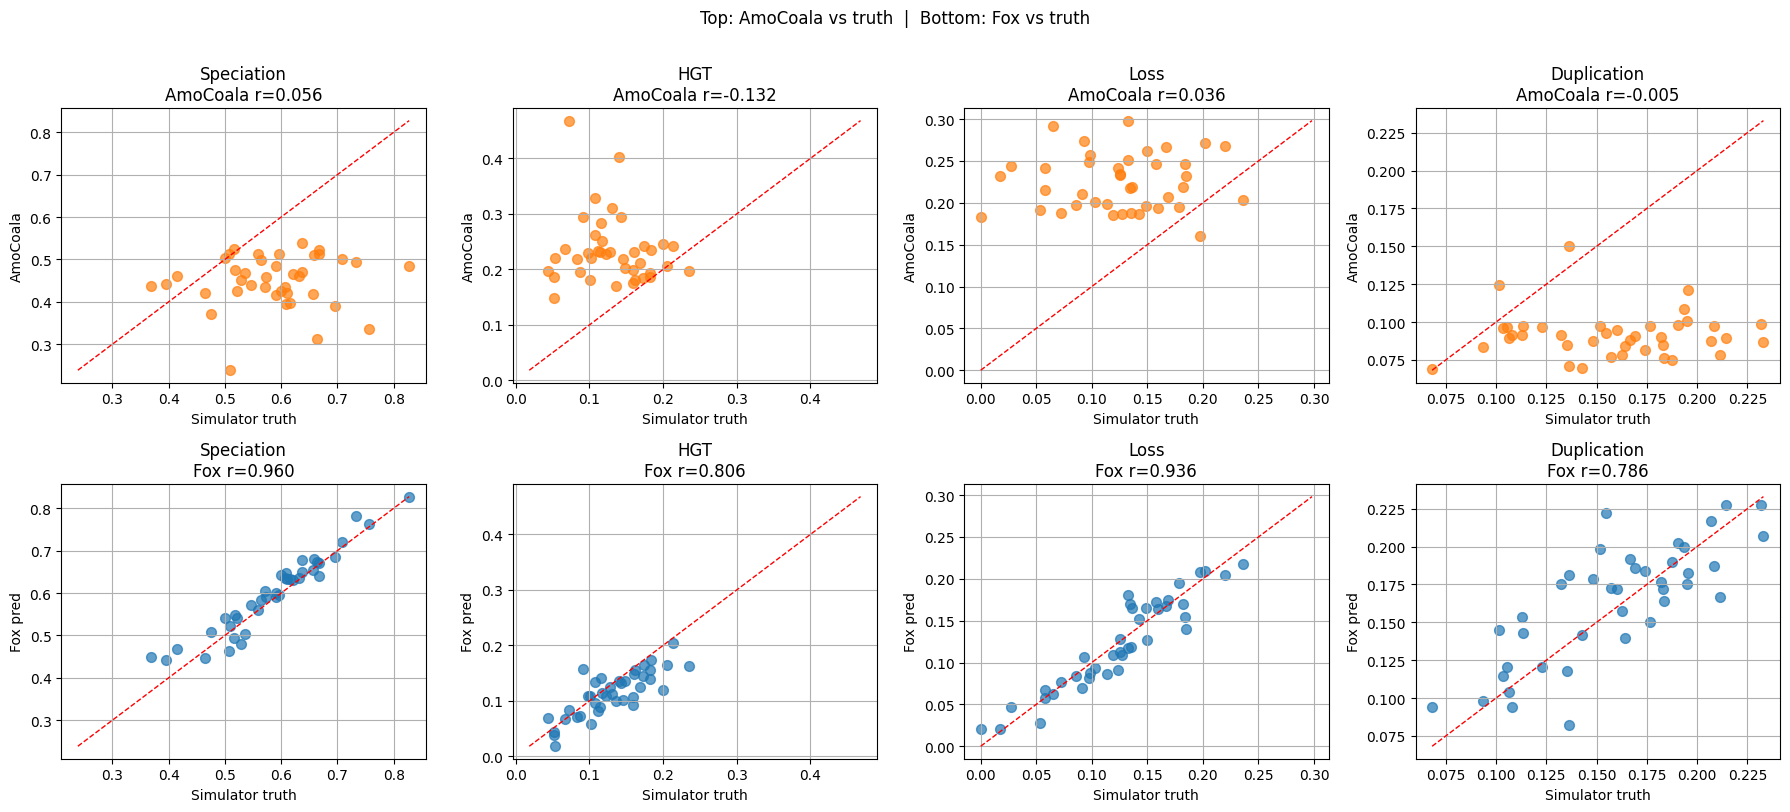

In [32]:
# ── 3-way scatter: truth vs AmoCoala vs model ────────────────────────────────
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for col, event in enumerate(EVENT_NAMES):
    t = df_cmp3[f'true_{event}'].values
    a = df_cmp3[f'ac_{event}'].values
    p = df_cmp3[f'pred_{event}'].values
    lo = min(t.min(), a.min(), p.min())
    hi = max(t.max(), a.max(), p.max())
    ax = axes[0, col]
    ax.scatter(t, a, alpha=0.7, s=50, color='C1')
    ax.plot([lo,hi], [lo,hi], 'r--', lw=1)
    r_ac = stats.pearsonr(t, a)[0]
    ax.set_title(f'{event}\nAmoCoala r={r_ac:.3f}')
    ax.set_xlabel('Simulator truth'); ax.set_ylabel('AmoCoala'); ax.grid(True)
    ax = axes[1, col]
    ax.scatter(t, p, alpha=0.7, s=50, color='C0')
    ax.plot([lo,hi], [lo,hi], 'r--', lw=1)
    r_mdl = stats.pearsonr(t, p)[0]
    ax.set_title(f'{event}\nFox r={r_mdl:.3f}')
    ax.set_xlabel('Simulator truth'); ax.set_ylabel('Fox pred'); ax.grid(True)
plt.suptitle('Top: AmoCoala vs truth  |  Bottom: Fox vs truth', y=1.01)
plt.tight_layout()
plt.savefig("test_data/amocoala_vs_fox.png", dpi=120, bbox_inches="tight")
plt.show()


## Performance vs. tree size (host & parasite)

Does accuracy degrade on larger trees? Scatter and binned MAE for Fox and AmoCoala across both host and parasite leaf count.

Datasets with leaf info: 40


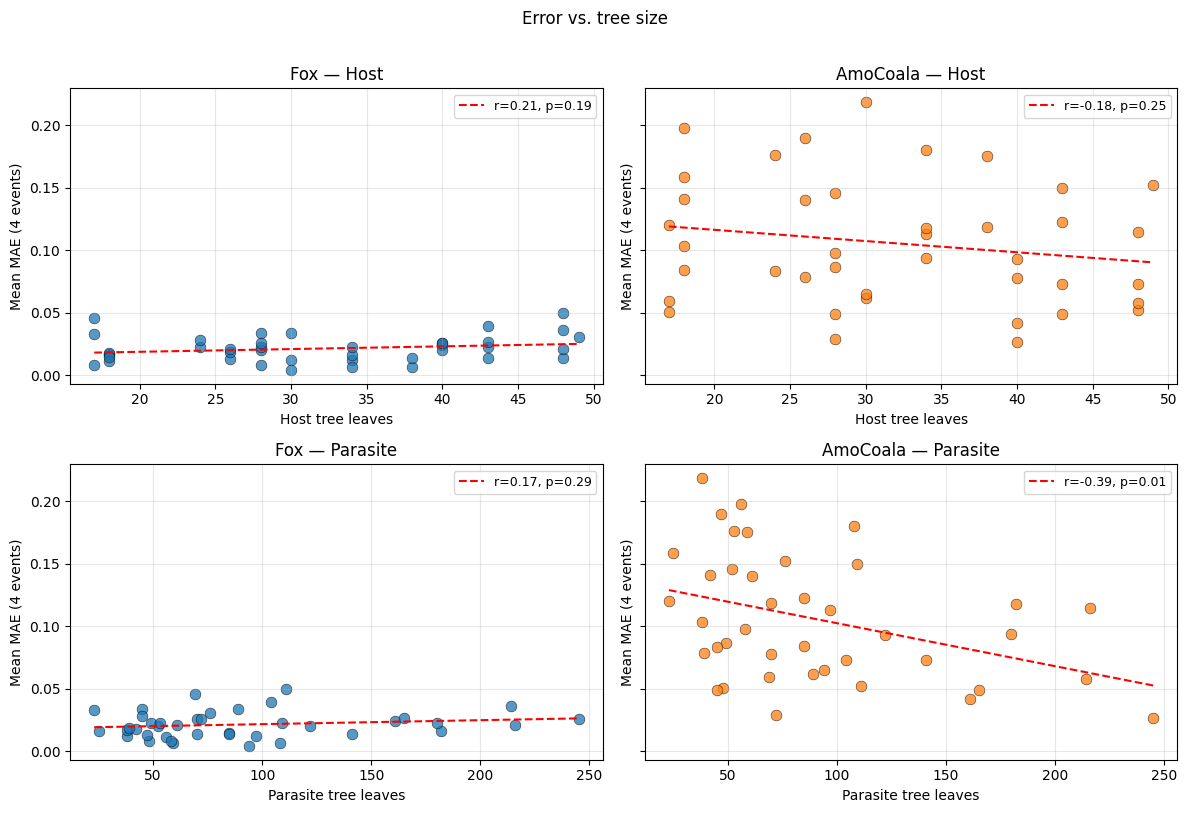


Binned MAE — Host leaves:
                  N  Fox MAE  AmoCoala MAE
Bin                                       
Small\n(≤26)     13   0.0207        0.1218
Medium\n(28–38)  14   0.0172        0.1109
Large\n(≥40)     13   0.0271        0.0835

Binned MAE — Parasite leaves:
                  N  Fox MAE  AmoCoala MAE
Bin                                       
Small\n(≤53)     13   0.0204        0.1232
Medium\n(56–94)  13   0.0198        0.1063
Large\n(≥97)     14   0.0242        0.0885


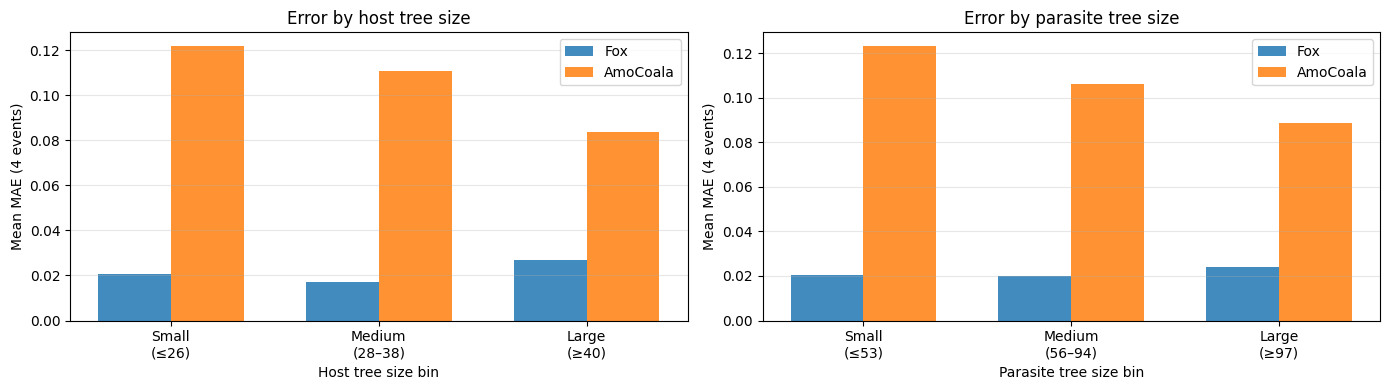

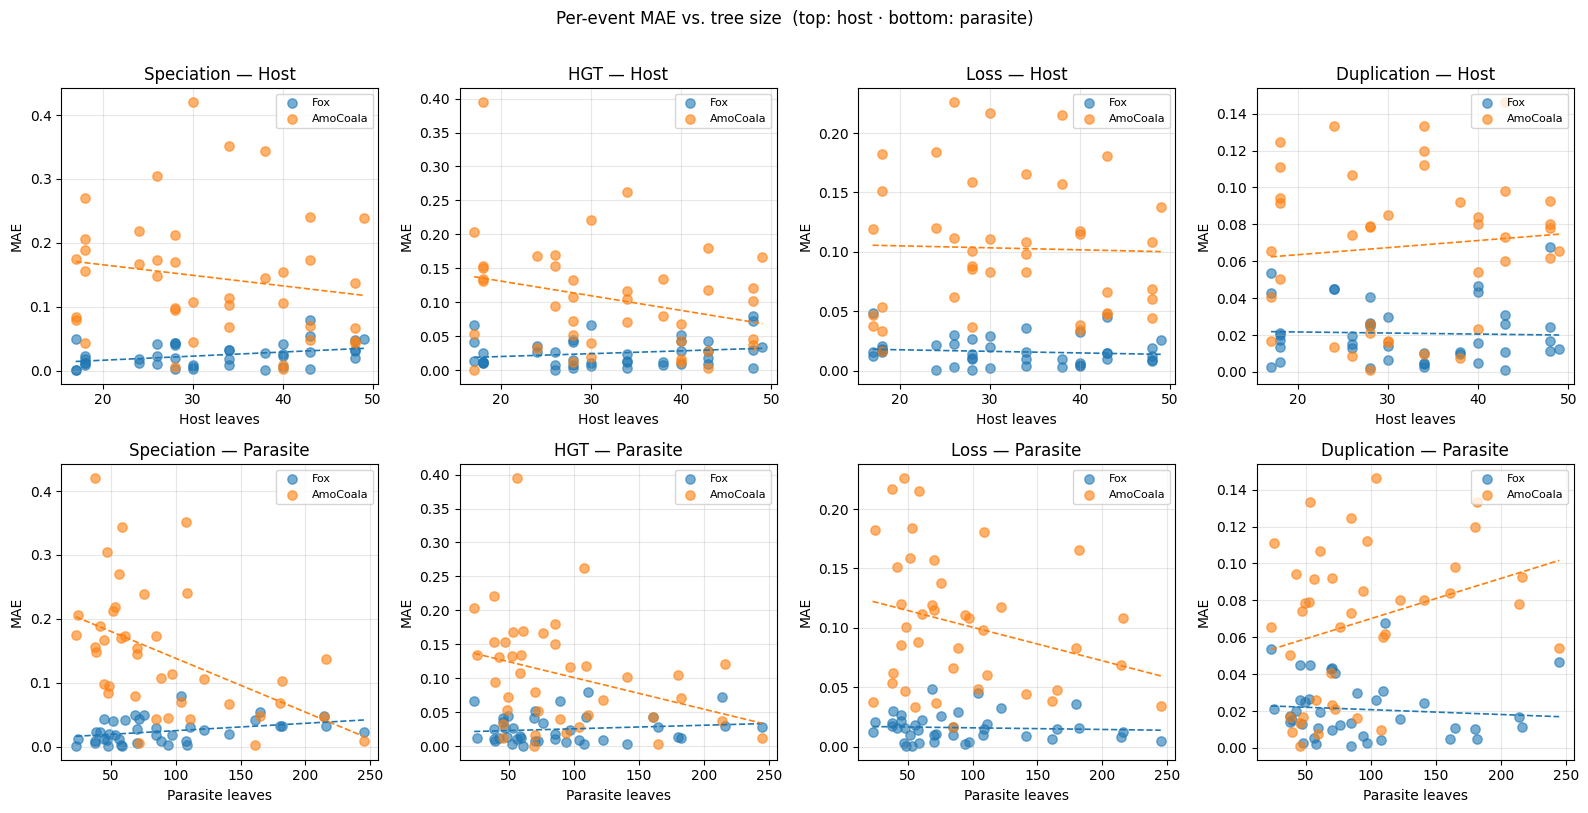

In [33]:
# ── Performance vs. tree size (host & parasite) ───────────────────────────────
import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats

TGL_DIR = "/Users/gabriele/Fox/test_data/Datasets"

leaf_rows = []
for tgl in sorted(__import__('glob').glob(f"{TGL_DIR}/*.tgl")):
    txt = open(tgl).read()
    h = re.search(r"Host_num_leaves: (\d+)", txt)
    s = re.search(r"Symbiont_num_leaves: (\d+)", txt)
    if h and s:
        leaf_rows.append({
            "file": __import__('os').path.basename(tgl),
            "host_leaves": int(h.group(1)),
            "sym_leaves":  int(s.group(1)),
        })

df_leaves = pd.DataFrame(leaf_rows)
df_sz = df_cmp3.merge(df_leaves, on="file", how="inner")
print(f"Datasets with leaf info: {len(df_sz)}")

for model_name, prefix in [("Fox", "pred"), ("AmoCoala", "ac")]:
    df_sz[f"mae_{model_name}"] = np.mean(
        [np.abs(df_sz[f"{prefix}_{e}"] - df_sz[f"true_{e}"]) for e in EVENT_NAMES], axis=0
    )

TREE_DIMS = [("host_leaves", "Host"), ("sym_leaves", "Parasite")]

# ── Figure 1: scatter MAE vs tree size (2 rows = host/para, 2 cols = model) ──
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
for row, (col_name, dim_label) in enumerate(TREE_DIMS):
    for ax, (model_name, color) in zip(axes[row], [("Fox", "C0"), ("AmoCoala", "C1")]):
        x = df_sz[col_name]
        y = df_sz[f"mae_{model_name}"]
        ax.scatter(x, y, alpha=0.75, s=60, color=color, edgecolors="k", linewidths=0.4)
        m, b, r, p, _ = stats.linregress(x, y)
        xl = np.array([x.min(), x.max()])
        ax.plot(xl, m * xl + b, "r--", lw=1.5, label=f"r={r:.2f}, p={p:.2f}")
        ax.set_xlabel(f"{dim_label} tree leaves")
        ax.set_ylabel("Mean MAE (4 events)")
        ax.set_title(f"{model_name} — {dim_label}")
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
plt.suptitle("Error vs. tree size", y=1.01)
plt.tight_layout()
plt.savefig("test_data/error_vs_treesize_scatter.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Figure 2: binned MAE bar chart (side-by-side host / parasite) ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, (col_name, dim_label) in zip(axes, TREE_DIMS):
    bins_cat = pd.qcut(df_sz[col_name], q=3, labels=["Small", "Medium", "Large"])
    bin_summary = []
    for b in bins_cat.cat.categories:
        sub = df_sz[bins_cat == b]
        lo, hi = sub[col_name].min(), sub[col_name].max()
        label = f"{b}\n(≤{hi})" if b == "Small" else (f"{b}\n(≥{lo})" if b == "Large" else f"{b}\n({lo}–{hi})")
        bin_summary.append({"Bin": label, "N": len(sub),
                             "Fox MAE": sub["mae_Fox"].mean(),
                             "AmoCoala MAE": sub["mae_AmoCoala"].mean()})
    df_bin = pd.DataFrame(bin_summary).set_index("Bin")
    print(f"\nBinned MAE — {dim_label} leaves:")
    print(df_bin.round(4))
    x_pos = np.arange(len(df_bin)); w = 0.35
    ax.bar(x_pos - w/2, df_bin["Fox MAE"],  w, label="Fox",  color="C0", alpha=0.85)
    ax.bar(x_pos + w/2, df_bin["AmoCoala MAE"], w, label="AmoCoala", color="C1", alpha=0.85)
    ax.set_xticks(x_pos); ax.set_xticklabels(df_bin.index)
    ax.set_ylabel("Mean MAE (4 events)")
    ax.set_xlabel(f"{dim_label} tree size bin")
    ax.set_title(f"Error by {dim_label.lower()} tree size")
    ax.legend(); ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("test_data/error_vs_treesize_binned.png", dpi=120, bbox_inches="tight")
plt.show()

# ── Figure 3: per-event MAE vs tree size (2 rows = host/para, 4 cols = event) ─
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for row, (col_name, dim_label) in enumerate(TREE_DIMS):
    for ax, event in zip(axes[row], EVENT_NAMES):
        x = df_sz[col_name]
        for model_key, color, lbl in [("pred", "C0", "Fox"), ("ac", "C1", "AmoCoala")]:
            y = np.abs(df_sz[f"{model_key}_{event}"] - df_sz[f"true_{event}"])
            ax.scatter(x, y, alpha=0.6, s=45, color=color, label=lbl)
            m, b, r, p, _ = stats.linregress(x, y)
            xl = np.array([x.min(), x.max()])
            ax.plot(xl, m * xl + b, "--", color=color, lw=1.2)
        ax.set_title(f"{event} — {dim_label}")
        ax.set_xlabel(f"{dim_label} leaves")
        ax.set_ylabel("MAE")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
plt.suptitle("Per-event MAE vs. tree size  (top: host · bottom: parasite)", y=1.01)
plt.tight_layout()
plt.savefig("test_data/error_vs_treesize_per_event.png", dpi=120, bbox_inches="tight")
plt.show()


## Real-data test: Heliconius Müllerian mimicry


In [22]:
# ── 1. Show dataset contents ──────────────────────────────────────────────────
import pandas as pd

TGL_PATH = "test_data/real_data/heliconius_mimicry.tgl"
NEX_PATH = "test_data/real_data/heliconius.nex"
MAP_PATH = "test_data/real_data/heliconius_specimen_map.xlsx"

d = parse_tgl(TGL_PATH)
host_msa  = d["host_msa"]
para_msa  = d["para_msa"]
dist_pairs = d["distribution"]

# Specimen cross-reference
spec_map = pd.read_excel(MAP_PATH)
short_to_fig = dict(zip(spec_map["Short_name"], spec_map["Name_figure"]))

print("HOST (H. erato)")
for s in host_msa:
    print(f"  {s:12s}  {short_to_fig.get(s,'')}")

print()
print("PARASITE (H. melpomene) ")
for s in para_msa:
    print(f"  {s:12s}  {short_to_fig.get(s,'')}")

print()
print("Associations")
for p, h in dist_pairs:
    print(f"  {p:12s} : {h:12s}   {short_to_fig.get(p,''):25s} ↔ {short_to_fig.get(h,'')}")


HOST (H. erato)
  Herato25      emma (East Pe)
  Herato48      favorinus (East Pe)
  Herato38      etylus (East E)
  Herato75      lativitta (East E)
  Herato30      erato (East FG)
  Herato61      hydara (East FG)
  Herato69      hydara (East T)
  Herato65      hydara (West Pa)
  Herato81      petiverana (West CR)
  Herato87      petiverana (West Pa)
  Herato56      hydara (East C)
  Herato21      cyrbia (West E)

PARASITE (H. melpomene) 
  Hmelpo98      aglaope (East Pe)
  Hmelp102      amaryllis (East Pe)
  Hmelp110      ecuadoriensis (East E)
  Hmelp246      malleti (East E)
  Hmelp161      thelxiopeia (East FG)
  Hmelp129      melpomene (East FG)
  Hmelp168      melpomene (East T)
  Hmelp132      melpomene (West Pa)
  Hmelp136      rosina (West CR)
  Hmelp133      rosina (West Pa)
  Hmelp100      melpomene (East C)
  Hmelp134      cythera (West E)

Associations
  Hmelp134     : Herato21       cythera (West E)          ↔ cyrbia (West E)
  Hmelp136     : Herato81       rosina (West 

In [ ]:
# ── 3a. Fox prediction ────────────────────────────────────────────────────
# Real data: no simulation time available. Pass sim_time=None and let the model
# fall back to its internal zero-tensor branch (see model.py L693-694).
import torch

host_tok = torch.stack([encode_sequence(seq) for seq in host_msa.values()])
para_tok = torch.stack([encode_sequence(seq) for seq in para_msa.values()])
host_dist_t = jukes_cantor_dist(host_tok)
para_dist_t = jukes_cantor_dist(para_tok)
h_idx2 = {n: i for i, n in enumerate(host_msa)}
p_idx2 = {n: i for i, n in enumerate(para_msa)}
mappings = [(h_idx2[h], p_idx2[p]) for p, h in dist_pairs if p in p_idx2 and h in h_idx2]

with torch.no_grad():
    out = model(
        host_tok.unsqueeze(0).to(device),
        para_tok.unsqueeze(0).to(device),
        [mappings],
        None, 
        host_dist=host_dist_t.unsqueeze(0).to(device),
        para_dist=para_dist_t.unsqueeze(0).to(device),
    )

fox_pred = dict(zip(EVENT_NAMES, out.squeeze(0).cpu().tolist()))
print("Fox prediction on Heliconius mimicry dataset (no sim_time):")
print(f"  {'Event':12s}  {'Prediction':>10s}")
print(f"  {'-'*25}")
for e, v in fox_pred.items():
    print(f"  {e:12s}  {v:10.4f}")
print(f"\n  Dominant signal: {max(fox_pred, key=fox_pred.get)} ({max(fox_pred.values()):.1%})")


Fox prediction on Heliconius mimicry dataset (no sim_time):
  Event         Prediction
  -------------------------
  Speciation        0.6834
  HGT               0.0224
  Loss              0.0447
  Duplication       0.2495

  Dominant signal: Speciation (68.3%)


In [26]:
# ── 3b. AmoCoala on heliconius.nex ───────────────────────────────────────────
import subprocess, os

AMOCOALA_JAR = "/Users/gabriele/AmoCoala-main/AmoCoala.jar"
NEX = "test_data/real_data/heliconius.nex"
AC_CSV = NEX + ".accep.round_1.csv"

if not os.path.exists(AC_CSV):
    print("Running AmoCoala...")
    r = subprocess.run(
        f"java -jar {AMOCOALA_JAR} -input {NEX} -N 2000 -M 100 -R 1 -t 0.1",
        shell=True, capture_output=True, text=True, timeout=6000
    )
    print(r.stdout[-500:] if r.stdout else "")
    print(r.stderr[-500:] if r.stderr else "")
else:
    print(f"Reusing existing result: {AC_CSV}")

# Parse AmoCoala result
if os.path.exists(AC_CSV):
    rows = []
    with open(AC_CSV) as f:
        for line in f:
            vals = [float(x) for x in line.strip().split("\t") if x.strip()]
            if len(vals) >= 4:
                rows.append(vals)
    arr = np.array(rows)
    cospec, dup, hsw, loss = arr[:,0].mean(), arr[:,1].mean(), arr[:,2].mean(), arr[:,3].mean()
    total = cospec + dup + hsw + loss or 1.0
    ac_pred = {
        "Speciation":  cospec / total,
        "HGT":         hsw    / total,
        "Loss":        loss   / total,
        "Duplication": dup    / total,
    }
    print(f"\nAmoCoala result ({len(rows)} accepted solutions):")
    print(f"  {'Event':12s}  {'Prediction':>10s}")
    print(f"  {'-'*25}")
    for e, v in ac_pred.items():
        print(f"  {e:12s}  {v:10.4f}")
    print(f"\n  Dominant signal: {max(ac_pred, key=ac_pred.get)} ({max(ac_pred.values()):.1%})")
else:
    ac_pred = None
    print("AmoCoala did not produce output.")


Reusing existing result: test_data/real_data/heliconius.nex.accep.round_1.csv

AmoCoala result (200 accepted solutions):
  Event         Prediction
  -------------------------
  Speciation        0.3883
  HGT               0.2094
  Loss              0.2991
  Duplication       0.1032

  Dominant signal: Speciation (38.8%)


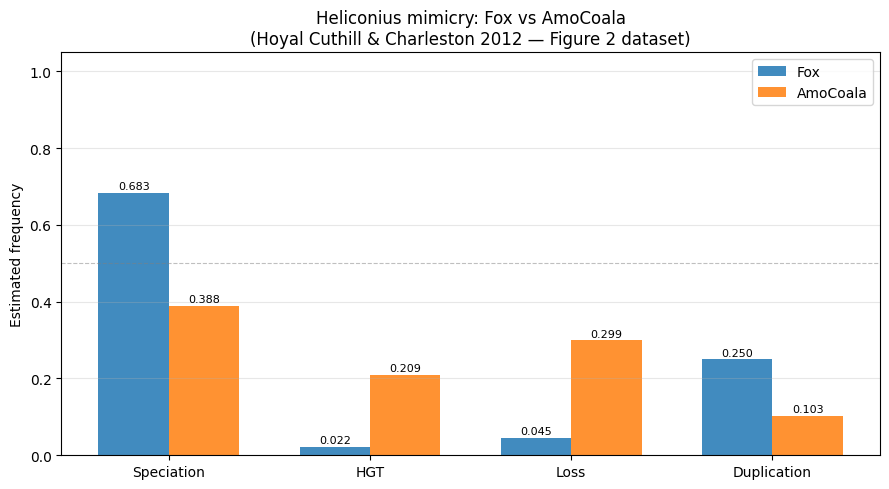

Saved: test_data/heliconius_fox_vs_amocoala.png

Summary:
  Event              Fox  AmoCoala      Diff
  --------------------------------------------
  Speciation      0.6834    0.3883   +0.2951
  HGT             0.0224    0.2094   -0.1870
  Loss            0.0447    0.2991   -0.2544
  Duplication     0.2495    0.1032   +0.1464

  Expected: both tools should agree on high Speciation
  (parallel cospeciation = textbook case for this dataset)


In [34]:
# ── 4. Compare Fox vs AmoCoala on real Heliconius data ───────────────────
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np

if ac_pred is None:
    print("AmoCoala result not available — skipping comparison.")
else:
    events = EVENT_NAMES
    x = np.arange(len(events))
    w = 0.35

    fig, ax = plt.subplots(figsize=(9, 5))
    bars_p = ax.bar(x - w/2, [fox_pred[e] for e in events], w,
                    label="Fox", color="C0", alpha=0.85)
    bars_a = ax.bar(x + w/2, [ac_pred[e]     for e in events], w,
                    label="AmoCoala", color="C1", alpha=0.85)

    for bar in list(bars_p) + list(bars_a):
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.005, f"{h:.3f}",
                ha="center", va="bottom", fontsize=8)

    ax.set_xticks(x); ax.set_xticklabels(events)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("Estimated frequency")
    ax.set_title("Heliconius mimicry: Fox vs AmoCoala\n"
                 "(Hoyal Cuthill & Charleston 2012 — Figure 2 dataset)")
    ax.legend()
    ax.axhline(0.5, color="gray", lw=0.8, ls="--", alpha=0.5)
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("test_data/heliconius_fox_vs_amocoala.png", dpi=120, bbox_inches="tight")
    plt.show()
    print("Saved: test_data/heliconius_fox_vs_amocoala.png")

    # ── Summary table ──────────────────────────────────────────────────────────
    print("\nSummary:")
    print(f"  {'Event':12s}  {'Fox':>8s}  {'AmoCoala':>8s}  {'Diff':>8s}")
    print(f"  {'-'*44}")
    for e in events:
        p, a = fox_pred[e], ac_pred[e]
        print(f"  {e:12s}  {p:8.4f}  {a:8.4f}  {p-a:+8.4f}")
    print()
    print("  Expected: both tools should agree on high Speciation")
    print("  (parallel cospeciation = textbook case for this dataset)")
